# Task 1 — Hellinger Distance Decision Tree (HDDT)

This notebook completes Part 2 of the homework. The implementation itself is in `task1_hddt.py` so it is also executable as a normal Python source file, as requested by the homework. The notebook uses markdown before every code cell to explain the preprocessing, HDDT formula, evaluation metrics, and pruning experiment.


## Imports and Shared Task Code

The homework allows scikit-learn only for preprocessing and metrics, not for the core classifier. The `HDDT` class imported below is implemented from scratch in `task1_hddt.py`; scikit-learn is used only for train/test splitting, imputation, scaling, and metric calculations.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / "code"))

from task1_hddt import (
    DEPTH_VALUES,
    SEEDS,
    HDDT,
    compute_metrics,
    plot_pruning_results,
    preprocess_train_test,
    resolve_dataset_path,
    run_hddt_experiments,
    run_pruning_experiment,
    summarize_metrics,
)


## Load Dataset and Report Missing Values

The target is `Label`, where `+1` is the severe/minority class and `-1` is the non-severe/majority class. Before any model is trained, we report the missing-value percentage for every column using:

`missing_percent = df.isnull().mean() * 100`


In [2]:
data_path = resolve_dataset_path("../Covid.csv")
df = pd.read_csv(data_path)

print(f"Dataset path: {data_path}")
print(f"Dataset shape: {df.shape}")
print("Class distribution:")
print(df["Label"].value_counts().sort_index())

missing_report = (
    df.isnull()
      .mean()
      .mul(100)
      .round(2)
      .rename("missing_percent")
      .reset_index()
      .rename(columns={"index": "column"})
)
missing_report


Dataset path: ../Covid.csv
Dataset shape: (1585, 41)
Class distribution:
Label
-1    1485
 1     100
Name: count, dtype: int64


,column,missing_percent
0,age,0.00
1,gender,0.00
2,contact with patient,0.00
3,Fever,0.00
4,Cough,0.00
5,Muscular pain,0.00
6,Shortness of breath,0.00
7,Inability to wake,0.00
8,loss of smell,0.00
9,loss of taste,1.70


## Preprocessing Used Before HDDT

This cell reuses the required preprocessing from Part 1.3 inside the Task 1 workflow, so each train/test split is processed independently and without leakage:

1. Stratified 70/30 split.
2. Median imputation for numeric ordinal fields and mode imputation for binary/categorical fields.
3. Kendall feature selection on training data only: remove one feature from each pair with `|tau| > 0.5`, keeping the one more correlated with `Label`.
4. StandardScaler only for retained true continuous features. In this CSV no true continuous feature is detected, so scaling is correctly skipped.


In [3]:
X_train, X_test, y_train, y_test, preprocessing_info = preprocess_train_test(df, seed=42)

print(f"Train shape after preprocessing: {X_train.shape}")
print(f"Test shape after preprocessing: {X_test.shape}")
print(f"Number of selected features: {len(preprocessing_info['selected_features'])}")
print(f"Continuous scaled features: {preprocessing_info['continuous_scaled']}")

preprocessing_info["removed_features"]


Train shape after preprocessing: (1109, 39)
Test shape after preprocessing: (476, 39)
Number of selected features: 39
Continuous scaled features: []


,removed_feature,kept_feature,abs_kendall_between_features,removed_abs_corr_with_label,kept_abs_corr_with_label
0,vomiting,nausea,0.766494,0.075083,0.075083


## Hellinger Split Criterion

At each node, HDDT searches all candidate feature thresholds and chooses the one with the largest Hellinger score:

$$
H_f = \left(\sqrt{\frac{p_L}{P}} - \sqrt{\frac{n_L}{N}}\right)^2 +
      \left(\sqrt{\frac{p_R}{P}} - \sqrt{\frac{n_R}{N}}\right)^2
$$

where `P` and `N` are total positive/negative counts at the node, and `p_L`, `n_L`, `p_R`, `n_R` are the class counts in the left and right child nodes. This normalization makes the split criterion less biased toward the majority class than Gini or information gain.


In [4]:
model = HDDT(min_samples_split=10, max_depth=None)
model.fit(X_train, y_train)

single_split_predictions = model.predict(X_test)
single_split_probabilities = model.predict_proba(X_test)

pd.DataFrame([compute_metrics(y_test, single_split_predictions, single_split_probabilities)]).round(4)


,Accuracy,Precision (+1),Recall (+1),F1-score (+1),AUC-ROC,G-mean
0,0.9055,0.1053,0.0667,0.0816,0.5395,0.2532


## Required 10-Run Evaluation

The homework requires 10 independent experiments using train/test split seeds `0` through `9`. Each run fits preprocessing only on that run's training data, trains HDDT, and reports Accuracy, Precision, Recall, F1, AUC-ROC, and G-mean.

The G-mean is:

$$
G\text{-}mean = \sqrt{Sensitivity \times Specificity}
$$

where `Sensitivity` is minority-class recall and `Specificity` is majority-class recall.


In [5]:
default_results = run_hddt_experiments(df, max_depth=None, seeds=SEEDS)
default_summary = summarize_metrics(default_results)

default_summary.round(4)


,Metric,Mean (10 runs),Std Dev
0,Accuracy,0.9109,0.0138
1,Precision (+1),0.1562,0.0945
2,Recall (+1),0.0833,0.0503
3,F1-score (+1),0.1023,0.0564
4,AUC-ROC,0.5846,0.0186
5,G-mean,0.2710,0.0868


## Per-Seed Results for the Unpruned HDDT

This table is useful for debugging variance across the 10 random train/test splits. The homework report should primarily include the mean and standard deviation table above.


In [6]:
default_results.round(4)


,Accuracy,Precision (+1),Recall (+1),F1-score (+1),AUC-ROC,G-mean,seed,max_depth,n_features
0,0.9139,0.0769,0.0333,0.0465,0.5927,0.1801,0,None,39
1,0.9328,0.2500,0.0333,0.0588,0.5968,0.1820,1,None,39
2,0.8971,0.1724,0.1667,0.1695,0.6101,0.3971,2,None,38
3,0.9118,0.2000,0.1333,0.1600,0.5927,0.3585,3,None,39
4,0.9076,0.1500,0.1000,0.1200,0.5677,0.3101,4,None,39
5,0.8866,0.1000,0.1000,0.1000,0.5836,0.3065,5,None,39
6,0.9097,0.0667,0.0333,0.0444,0.6062,0.1797,6,None,39
7,0.9307,0.3636,0.1333,0.1951,0.5508,0.3623,7,None,37
8,0.9139,0.0769,0.0333,0.0465,0.5698,0.1801,8,None,39
9,0.9055,0.1053,0.0667,0.0816,0.5760,0.2532,9,None,39


## Pruning Experiment

The pruning experiment repeats the 10-run evaluation for:

`max_depth in {None, 2, 3, 4, 5}`

`max_depth=None` means the tree grows until another stopping condition is met. Shallow trees usually have higher bias; very deep trees can overfit, especially with small minority-class leaves.


In [ ]:
pruning_results, pruning_summary = run_pruning_experiment(df, depth_values=DEPTH_VALUES, seeds=SEEDS)
pruning_summary.round(4)

max_depth Accuracy         Precision (+1)         Recall (+1)          \
                mean     std           mean     std        mean     std   
0         2   0.9370  0.0000         0.0000  0.0000      0.0000  0.0000   
1         3   0.9366  0.0013         0.0000  0.0000      0.0000  0.0000   
2         4   0.9353  0.0041         0.0000  0.0000      0.0000  0.0000   
3         5   0.9340  0.0039         0.0250  0.0791      0.0033  0.0105   
4      None   0.9109  0.0138         0.1562  0.0945      0.0833  0.0503   

  F1-score (+1)         AUC-ROC          G-mean          
           mean     std    mean     std    mean     std  
0        0.0000  0.0000  0.5439  0.0109  0.0000  0.0000  
1        0.0000  0.0000  0.5560  0.0161  0.0000  0.0000  
2        0.0000  0.0000  0.5742  0.0299  0.0000  0.0000  
3        0.0059  0.0186  0.5818  0.0299  0.0182  0.0575  
4        0.1023  0.0564  0.5846  0.0186  0.2710  0.0868

## Plot F1 and G-mean vs. Max Depth

The homework asks for F1 and G-mean curves versus `max_depth`. G-mean is especially important here because predicting almost everything as `-1` can still produce high accuracy on this imbalanced dataset, while G-mean becomes zero if minority recall is zero.


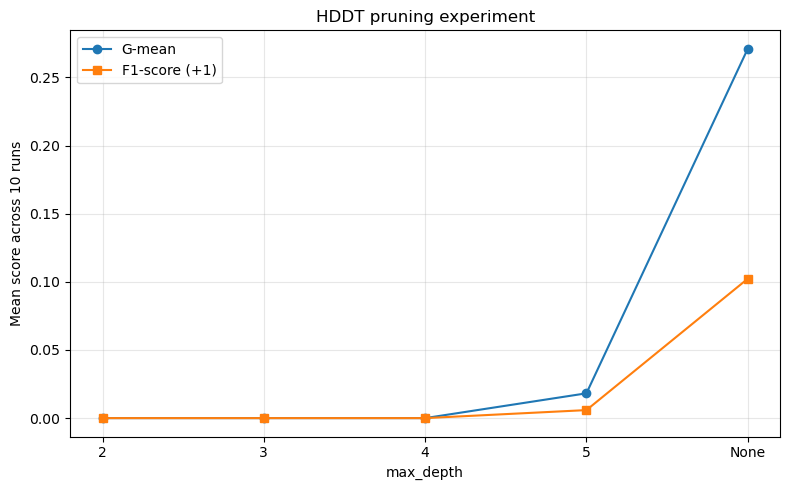

In [8]:
import importlib
import task1_hddt

importlib.reload(task1_hddt)
ax = task1_hddt.plot_pruning_results(pruning_results)
plt.show()


## Best Depth by Bias-Variance Tradeoff

For this dataset and implementation, the table below chooses the depth with the largest mean G-mean, using F1 as a secondary tie-breaker. This is a better criterion than accuracy because the dataset has roughly a 15:1 class imbalance.


In [9]:
best_depth_table = (
    pruning_results
    .groupby("max_depth")[["G-mean", "F1-score (+1)", "Recall (+1)", "Precision (+1)", "Accuracy", "AUC-ROC"]]
    .mean()
    .sort_values(["G-mean", "F1-score (+1)"], ascending=False)
)

best_depth_table.round(4)


,G-mean,F1-score (+1),Recall (+1),Precision (+1),Accuracy,AUC-ROC
max_depth,,,,,,
None,0.2710,0.1023,0.0833,0.1562,0.9109,0.5846
5,0.0182,0.0059,0.0033,0.0250,0.9340,0.5818
2,0.0000,0.0000,0.0000,0.0000,0.9370,0.5439
3,0.0000,0.0000,0.0000,0.0000,0.9366,0.5560
4,0.0000,0.0000,0.0000,0.0000,0.9353,0.5742
